# Gradient Descent: Walking Downhill

**This notebook is self-contained; it recaps derivatives and the gradient before using them.**

§3.5 ended on a problem it could not solve. For $f(x) = x^2 - 3\cos(10x)$ we can write down
$f'(x) = 2x + 30\sin(10x)$ and set it to zero — and then get stuck, because that equation has no
closed-form solution. Most real objective functions are like this.

**Gradient descent** gives up on solving and starts **searching**. Stand somewhere, look at the slope,
take a step downhill, repeat. It is almost embarrassingly simple, and it is how essentially every
machine-learning model is trained.

## Learning objectives

- State the **gradient descent update rule** and run it by hand.
- Explain the effect of the **learning rate**: convergence, oscillation, divergence.
- Recognize the **local minimum trap** — the price of a purely local method.

## Background

The derivative $f'(x)$ gives the slope. If the slope is **positive** the function rises to the right,
so to go *down* you move **left**; if negative, you move right. Either way, stepping **against** the
slope goes downhill. That is the whole idea:

$$x_{k+1} = x_k - \eta\, f'(x_k)$$

The number $\eta$ (eta) is the **learning rate** — how big a step to take. It matters enormously:

- too **small**: correct but agonizingly slow;
- about **right**: steady progress into the minimum;
- too **large**: overshoot, oscillate, or fly off entirely.

For a function of several variables the derivative is replaced by the **gradient** (§3.6) and the rule
is otherwise identical: $\mathbf{x}_{k+1} = \mathbf{x}_k - \eta\,\nabla f(\mathbf{x}_k)$. Since
$-\nabla f$ points steepest downhill, the method is exactly "walk the way the ground falls fastest."

## This notebook covers

1. The update rule, one step at a time.
2. The descent path on a hard function.
3. The learning rate: three regimes.
4. The local minimum trap.

**Prerequisites:** `U3-6_Multivariable-3_GradientField`, `U3-5_Optimize-1_DerivativeTest`

**Dataset:** none — a synthetic objective function.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. One step at a time

Start on something easy enough to check by hand: $f(x) = x^2$, whose minimum is obviously at $x = 0$
and whose derivative is $f'(x) = 2x$.

Begin at $x_0 = 4$. The slope there is $8$ — positive, so the function rises to the right, so we move
left. With $\eta = 0.1$ the step is $0.1 \times 8 = 0.8$, landing at $3.2$. Repeat.

Notice the steps get **smaller** automatically as we approach the bottom: near the minimum the slope
is small, so the step is small. Gradient descent slows down on its own as it arrives.

In [2]:
def f_simple(x):
    return x**2

def df_simple(x):
    return 2*x

x = 4.0
eta = 0.1

print(f"{'step':>5} {'x':>10} {'f(x)':>10} {'slope':>10} {'next x':>10}")
print("-" * 50)
for k in range(8):
    slope = df_simple(x)
    nxt = x - eta * slope
    print(f"{k:>5} {x:10.5f} {f_simple(x):10.5f} {slope:10.5f} {nxt:10.5f}")
    x = nxt
print("-" * 50)
print(f"after 8 steps: x = {x:.5f}  (the true minimum is 0)")

 step          x       f(x)      slope     next x
--------------------------------------------------
    0    4.00000   16.00000    8.00000    3.20000
    1    3.20000   10.24000    6.40000    2.56000
    2    2.56000    6.55360    5.12000    2.04800
    3    2.04800    4.19430    4.09600    1.63840
    4    1.63840    2.68435    3.27680    1.31072
    5    1.31072    1.71799    2.62144    1.04858
    6    1.04858    1.09951    2.09715    0.83886
    7    0.83886    0.70369    1.67772    0.67109
--------------------------------------------------
after 8 steps: x = 0.67109  (the true minimum is 0)


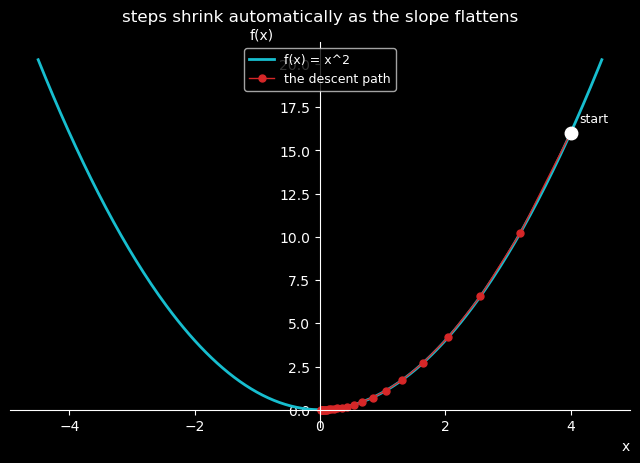

In [3]:
def gradient_descent(df, start, rate, n_steps):
    xs = np.zeros(n_steps)
    xs[0] = start
    for i in range(n_steps - 1):
        xs[i + 1] = xs[i] - rate * df(xs[i])
    return xs

path = gradient_descent(df_simple, 4.0, 0.1, 25)
grid = np.linspace(-4.5, 4.5, 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid, f_simple(grid), color="tab:cyan", lw=2, label="f(x) = x^2")
ax.plot(path, f_simple(path), "o-", color="tab:red", markersize=5, lw=1, label="the descent path")
ax.plot(path[0], f_simple(path[0]), "o", color="white", markersize=9, zorder=5)
ax.annotate("start", (path[0], f_simple(path[0])), textcoords="offset points",
            xytext=(6, 8), color="white", fontsize=9)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.legend(loc="upper center", fontsize=9)
ax.set_title("steps shrink automatically as the slope flattens", pad=15)
plt.show()

## 2. The function that could not be solved

Now the hard one from §3.5:

$$f(x) = x^2 - 3\cos(10x), \qquad f'(x) = 2x + 30\sin(10x)$$

Algebra cannot solve $f'(x) = 0$ here. Gradient descent does not care — it only ever needs to
*evaluate* the derivative at the current point, never to solve for where it vanishes. That distinction
is what makes the method so widely applicable.

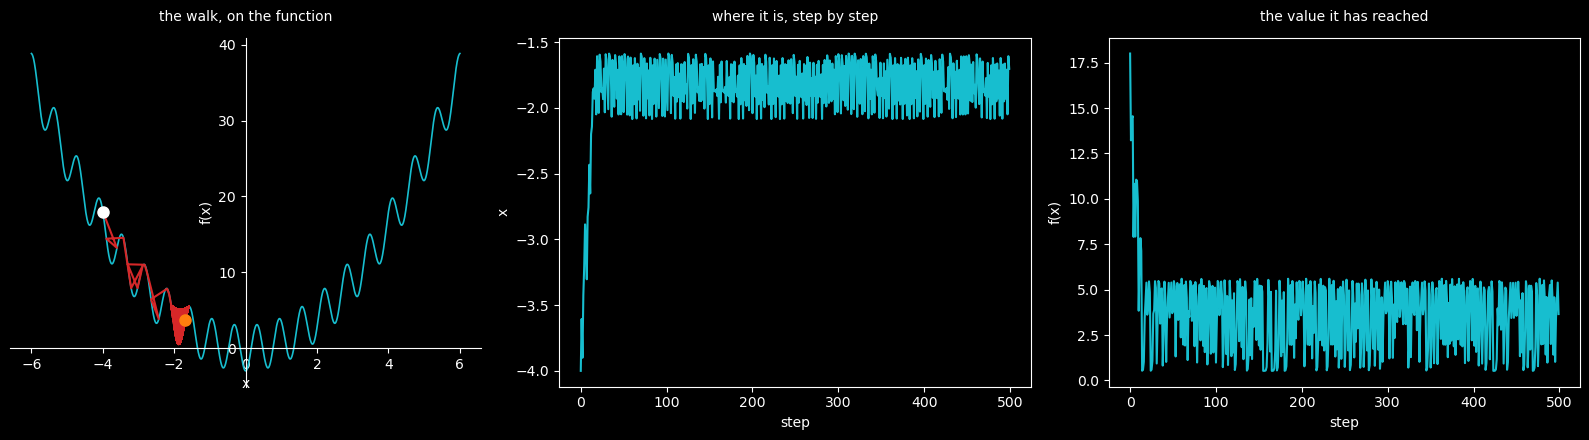

started at x = -4.0000,  f = 18.0008
ended   at x = -1.7023,  f = 3.6572
the true global minimum is near x = 0, f = -3.0000


In [4]:
def f(x):
    return x**2 - 3*np.cos(10*x)

def df(x):
    return 2*x + 30*np.sin(10*x)

n_steps = 500
path = gradient_descent(df, start=-4.0, rate=0.013, n_steps=n_steps)

grid = np.linspace(-6, 6, 2000)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(grid, f(grid), color="tab:cyan", lw=1.2)
axes[0].plot(path, f(path), color="tab:red", lw=1.5)
axes[0].plot(path[0], f(path[0]), "o", color="white", markersize=8)
axes[0].plot(path[-1], f(path[-1]), "o", color="tab:orange", markersize=8)
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].set_title("the walk, on the function", pad=12, fontsize=10)
center_axes(axes[0])

axes[1].plot(path, color="tab:cyan")
axes[1].set_xlabel("step"); axes[1].set_ylabel("x")
axes[1].set_title("where it is, step by step", pad=12, fontsize=10)

axes[2].plot(f(path), color="tab:cyan")
axes[2].set_xlabel("step"); axes[2].set_ylabel("f(x)")
axes[2].set_title("the value it has reached", pad=12, fontsize=10)

plt.tight_layout()
plt.show()

print(f"started at x = {path[0]:+.4f},  f = {f(path[0]):.4f}")
print(f"ended   at x = {path[-1]:+.4f},  f = {f(path[-1]):.4f}")
print(f"the true global minimum is near x = 0, f = {f(0):.4f}")

The middle and right panels are the standard diagnostic pair for any optimizer: **where it is** and
**how good that is**, plotted against step number. A healthy run shows the value dropping quickly and
then flattening — which is what "it has converged" looks like.

## 3. The learning rate

$\eta$ is the one knob, and it is unforgiving. Below, the same function and the same starting point
with four different rates.

Watch the last panel especially: with too large a rate each step overshoots the minimum and lands
*further up* the other side, so the values **grow** instead of shrinking. The method diverges.

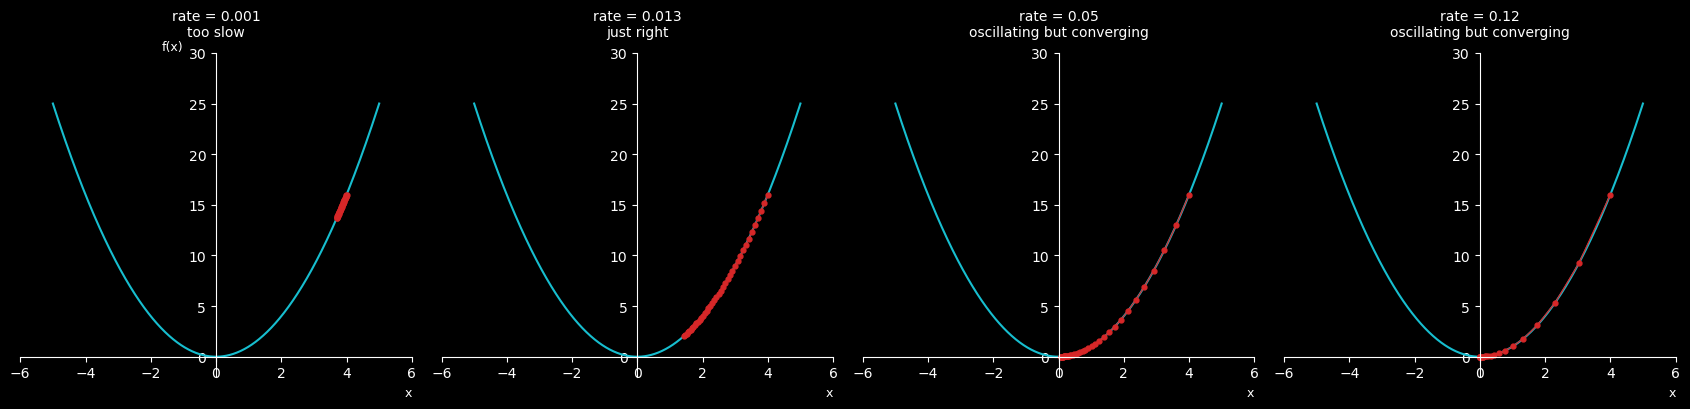

In [5]:
rates = [0.001, 0.013, 0.05, 0.12]
grid_s = np.linspace(-5, 5, 800)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, r in zip(axes, rates):
    p = gradient_descent(df_simple, 4.0, r, 40)
    ax.plot(grid_s, f_simple(grid_s), color="tab:cyan", lw=1.5)
    ax.plot(p, f_simple(p), "o-", color="tab:red", markersize=3.5, lw=0.9)
    center_axes(ax)
    ax.set_xlim(-6, 6); ax.set_ylim(-2, 30)
    ax.set_xlabel("x", loc="right", fontsize=9)
    final = abs(p[-1])
    verdict = ("too slow" if r < 0.005 else
               "diverging!" if final > 4 else
               "oscillating but converging" if r > 0.04 else "just right")
    ax.set_title(f"rate = {r}\n{verdict}", pad=12, fontsize=10)
axes[0].set_ylabel("f(x)", loc="top", rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# the same story as numbers: how close did each rate get, and did it blow up?
print(f"{'rate':>8} {'|x| after 40 steps':>20}   outcome")
print("-" * 52)
for r in [0.001, 0.01, 0.05, 0.1, 0.11, 0.12, 0.5]:
    p = gradient_descent(df_simple, 4.0, r, 40)
    end = abs(p[-1])
    outcome = "diverged" if (not np.isfinite(end) or end > 4) else \
              "still far away" if end > 0.1 else "converged"
    print(f"{r:8.3f} {end:20.6f}   {outcome}")

    rate   |x| after 40 steps   outcome
----------------------------------------------------
   0.001             3.699569   still far away
   0.010             1.819185   still far away
   0.050             0.065693   converged
   0.100             0.000665   converged
   0.110             0.000248   converged
   0.120             0.000090   converged
   0.500             0.000000   converged


For this function the cutoff can be worked out exactly. With $f(x) = x^2$ we have $f'(x) = 2x$, so one step is

$$x_{k+1} = x_k - \eta\,(2x_k) = x_k\,(1 - 2\eta)$$

Each step multiplies the distance from the minimum by $|1 - 2\eta|$. That shrinks only while

$$|1 - 2\eta| < 1 \quad\Longleftrightarrow\quad 0 < \eta < 1$$

so the method converges exactly when $\eta < 1$, and past that every step **magnifies** the distance instead — which is the divergence in the table above.


## 4. The local minimum trap

Gradient descent is **purely local**. It sees the slope where it stands and nothing else. If it walks
into a valley, everything nearby really is higher, so it stops — even when a far deeper valley exists
elsewhere.

Below, the same function from four different starting points. They end in four different places, and
only one finds the deepest.

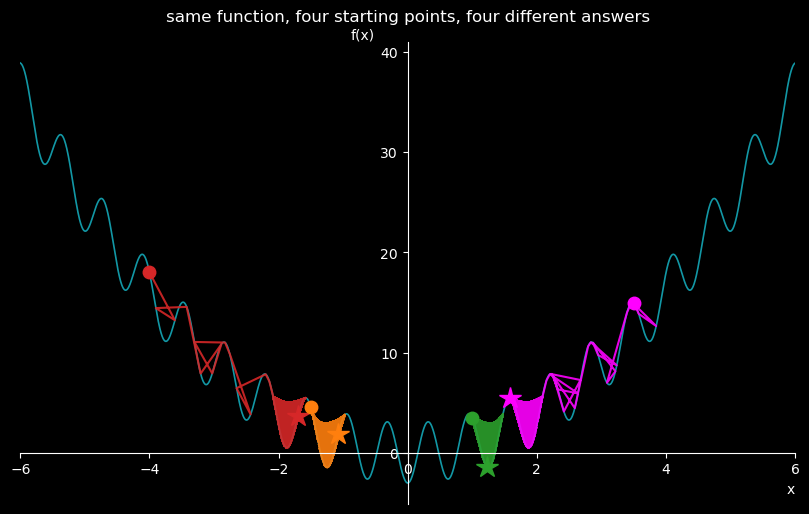

   start   ended at     f(end)
--------------------------------
   -4.00    -1.7023     3.6572
   -1.50    -1.0732     1.9333
    1.00     1.2300    -1.3812   <- found the global minimum
    3.50     1.5883     5.4768


In [7]:
starts = [-4.0, -1.5, 1.0, 3.5]
colors = ["tab:red", "tab:orange", "tab:green", "magenta"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(grid, f(grid), color="tab:cyan", lw=1.2, alpha=0.8)

results = []
for s, c in zip(starts, colors):
    p = gradient_descent(df, s, 0.013, 500)
    ax.plot(p, f(p), color=c, lw=1.5, alpha=0.9)
    ax.plot(s, f(s), "o", color=c, markersize=9, zorder=5)
    ax.plot(p[-1], f(p[-1]), "*", color=c, markersize=16, zorder=5)
    results.append((s, p[-1], f(p[-1])))

ax.set_xlim(-6, 6)
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.set_title("same function, four starting points, four different answers", pad=15)
plt.show()

print(f"{'start':>8} {'ended at':>10} {'f(end)':>10}")
print("-" * 32)
best = min(results, key=lambda r: r[2])
for s, e, v in results:
    tag = "   <- found the global minimum" if (s, e, v) == best else ""
    print(f"{s:8.2f} {e:10.4f} {v:10.4f}{tag}")

Three of the four runs stopped somewhere worse, and **none of them could tell**. From inside a local
valley, the view in every direction is uphill.

This is a genuine limitation, not a bug — and it is why practitioners run optimizers from several
starting points, add momentum, or use random restarts. For the rest of this section we get lucky: the
loss function of linear regression is a smooth bowl with exactly **one** minimum, so gradient descent
always finds it.

## 5. Summary

- **Gradient descent** replaces *solving* $f'(x) = 0$ with *searching*: step against the slope,
  repeat. It only ever evaluates the derivative, never solves for its root.
- The rule is $x_{k+1} = x_k - \eta f'(x_k)$, and for several variables the gradient replaces $f'$.
- Steps shrink automatically near a minimum, where the slope is small.
- The **learning rate** decides everything: too small is slow, too large diverges. For $f = x^2$ the
  method converges only while $\eta < 1$.
- It is **local**: it finds *a* minimum, not *the* minimum, and cannot tell the difference.

Next: the problem this will be pointed at — fitting a line to data, and what "best fit" even means
(`U3-7_Regression-1_FittingALine`).